**Polynomial Regression**

Polynomial regression is a form of regression analysis in which the relationship between the independent variable x and the dependent variable y is modelled as an nth degree polynomial in x. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

In [2]:
# Importing the dataset
dataset = pd.read_csv('C:/MAFAS/APU/EFREI/LAB MATERIALS/LAB 5 - Regression/Position_Salaries.csv')
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


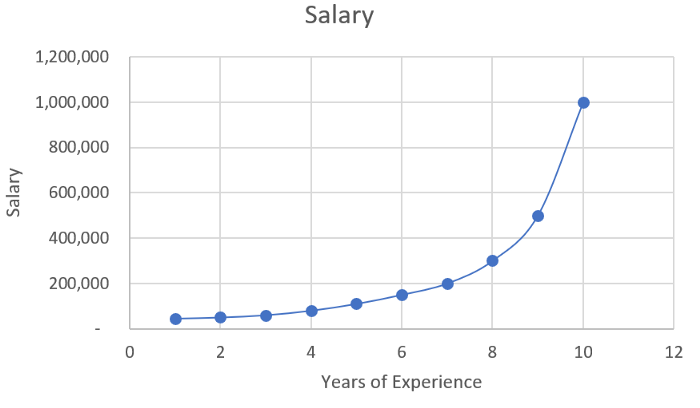

In [3]:
x = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [4]:
x

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [5]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [6]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


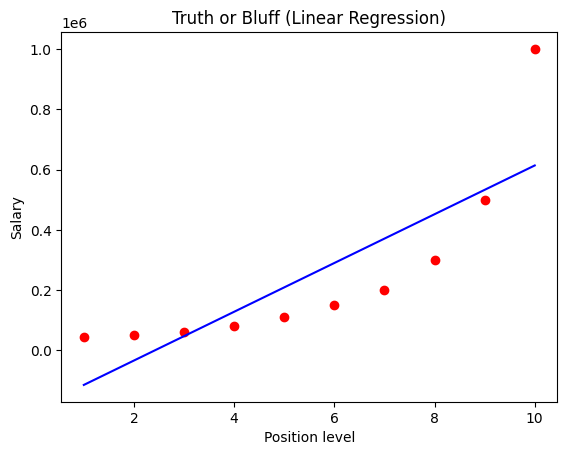

In [7]:
# Visualizing the Linear Regression results
def viz_linear():
    plt.scatter(x, y, color = 'red')
    plt.plot(x, lin_reg.predict(x), color = 'blue')
    plt.title('Truth or Bluff (Linear Regression)')
    plt.xlabel('Position level')
    plt.ylabel('Salary')
    plt.show()
    return
viz_linear()

In [8]:
# Evaluating Linear Regression
y_pred_1 = lin_reg.predict(x).round()
print(y_pred_1)
print("R Square value of Linear Regression:", r2_score(y, y_pred_1))

[-114455.  -33576.   47303.  128182.  209061.  289939.  370818.  451697.
  532576.  613455.]
R Square value of Linear Regression: 0.6690415021772886


In [9]:
# Comparing the actual and predicted 
pd.DataFrame({'Actual': y, 'Predicted': y_pred_1})

,Actual,Predicted
0,45000,-114455.0
1,50000,-33576.0
2,60000,47303.0
3,80000,128182.0
4,110000,209061.0
5,150000,289939.0
6,200000,370818.0
7,300000,451697.0
8,500000,532576.0
9,1000000,613455.0


In [10]:
# MSE, RMSE, MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y, y_pred_1), 2))
print('Mean Absolute Error: ', round(mean_absolute_error(y, y_pred_1), 2))  
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y, y_pred_1)), 2))

Mean Squared Error:  26695857091.0
Mean Absolute Error:  128454.6
Root Mean Squared Error:  163388.67


**Fitting Polynomial Regression to the dataset**

In [11]:
from sklearn.preprocessing import PolynomialFeatures
poly_fea = PolynomialFeatures(degree = 6)
x_poly = poly_fea.fit_transform(x)
pol_reg = LinearRegression()
pol_reg.fit(x_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**To get an overview of the increment of salary, let’s visualize the data set into a chart**

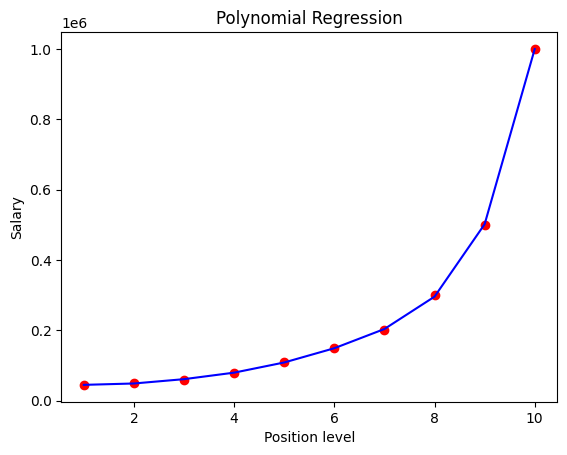

In [12]:
# Visualizing the Polymonial Regression results
def viz_polymonial():
    plt.scatter(x, y, color = 'red')
    plt.plot(x, pol_reg.predict(poly_fea.fit_transform(x)), color = 'blue')
    plt.title('Polynomial Regression')
    plt.xlabel('Position level')
    plt.ylabel('Salary')
    plt.show()
    return
viz_polymonial()

In [13]:
# Evaluating Polynomial Regression
y_pred_poly = pol_reg.predict(poly_fea.fit_transform(x)).round()
print(y_pred_poly)
print("R Square value of Polynomial Regression:", r2_score(y, y_pred_poly))

[ 45191.  49087.  61383.  79878. 108809. 149282. 203941. 295889. 501868.
 999673.]
R Square value of Polynomial Regression: 0.9999494685766886


In [14]:
# Comparing the actual and predicted 
pd.DataFrame({'Actual': y, 'Predicted': y_pred_poly})

,Actual,Predicted
0,45000,45191.0
1,50000,49087.0
2,60000,61383.0
3,80000,79878.0
4,110000,108809.0
5,150000,149282.0
6,200000,203941.0
7,300000,295889.0
8,500000,501868.0
9,1000000,999673.0


In [15]:
# MSE, RMSE, MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y, y_pred_poly), 2))
print('Mean Absolute Error: ', round(mean_absolute_error(y, y_pred_poly), 2))  
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y, y_pred_poly)), 2))

Mean Squared Error:  4075978.3
Mean Absolute Error:  1476.5
Root Mean Squared Error:  2018.91


**Use GridSearchCV to find the best polynomial degree**

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np

# Create pipeline
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures()),  
    ('linear_reg', LinearRegression())        
])

 # Degrees to test
params = {
    'poly_features__degree': np.arange(2, 10, 1) 
}


# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=pipeline, param_grid=params, scoring='r2', cv=3)
grid_search.fit(x, y)

# Get the best degree from the grid search
best_degree = grid_search.best_params_['poly_features__degree']
print(f"Best degree found:{best_degree}")

# Now we fit the model with the best degree
poly_fea = PolynomialFeatures(degree=best_degree)  
x_poly = poly_fea.fit_transform(x)
pol_reg = LinearRegression()
pol_reg.fit(x_poly, y)

# Predicting a new result with Polymonial Regression
y_pred_poly = pol_reg.predict(x_poly)
print()
print("R Square value of Polynomial Regression:", r2_score(y, y_pred_poly))

Best degree found:8

R Square value of Polynomial Regression: 0.9999934972438327
